### Here is the example of unbalanced data

In [1]:
import numpy as np

In [2]:
np.random.seed(50)
X = np.random.randn(1000,4)
Y = np.array([0]*950 + [1]*50)

In [3]:
majority_index = np.where(Y == 0)[0]
minority_index = np.where(Y == 1)[0]



In [4]:
n_minority = len(minority_index)

In [5]:
random_select_majority = np.random.choice(majority_index, size = n_minority, replace=False)
balance = np.concatenate([random_select_majority, minority_index])
np.random.shuffle(balance)

In [6]:
X_balanced = X[balance]
y_balanced = Y[balance]
print(X_balanced)

[[-1.40590395  0.98736187  1.12102816  1.16137531]
 [-0.74799406  0.22570931 -2.34998565 -0.40458933]
 [ 3.31407535  0.98777046  0.12386626  0.74278539]
 [-1.0514244  -1.12885839 -0.77938553 -0.40529608]
 [ 0.34479498 -1.33295508  0.61081003  0.09119902]
 [ 0.4072249  -0.06340153  1.55965917 -0.56815045]
 [ 0.846059    0.67599479 -0.80756587 -0.48501772]
 [ 1.07217032  0.69663212  3.14011468  1.31563878]
 [ 0.58069657  0.29862477  0.50841605  1.68739528]
 [ 0.14265235 -0.53171271 -1.31841553 -0.59803081]
 [ 1.30313897  0.50669242 -1.23136303 -0.08590879]
 [ 1.34084309  1.49069527  1.22991533 -0.57240571]
 [-0.22980135 -0.25458605  0.30291975 -0.13974744]
 [ 0.82920852  0.02443424  0.06227923  0.89301031]
 [-0.58341731 -0.33447652  0.26190878 -1.12976081]
 [-0.26719939  0.5022939   1.15440507  0.06672351]
 [ 0.08708825 -0.67321713  1.72052355 -0.33246159]
 [-0.94380718  0.22458732  0.02381274  0.08187712]
 [-1.02813556 -0.06815936  0.73776296 -0.51853566]
 [ 0.15305694 -0.35810908  1.03

In [7]:
print(f"Balanced shape - X: {X_balanced.shape}, y: {y_balanced.shape}")
print(f"Balanced class counts -> 0: {np.sum(y_balanced == 0)}, 1: {np.sum(y_balanced == 1)}")

Balanced shape - X: (100, 4), y: (100,)
Balanced class counts -> 0: 50, 1: 50


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [9]:
X = np.array([101, 106, 111, 119, 799, 123, 99, 100, 117, 666])
Y = np.array([100122, 19924, 10209, 10138, 21938, 34615, 99999, 12345, 12678])

X_2d = X.reshape(-1, 1)
Y_2d = Y.reshape(-1, 1)

scaler = StandardScaler()

Z_X = scaler.fit_transform(X_2d)
Z_Y = scaler.fit_transform(Y_2d)

print("Z-scores for X:\n", Z_X.flatten())
print("\nZ-scores for Y:\n", Z_Y.flatten())


Z-scores for X:
 [-0.5300867  -0.5101736  -0.4902605  -0.45839955  2.24978196 -0.44246907
 -0.53805194 -0.53406932 -0.46636479  1.72009352]

Z-scores for Y:
 [ 1.83206892 -0.45127743 -0.72787672 -0.72989818 -0.3939361  -0.03300464
  1.82856695 -0.66706189 -0.65758092]


### creating a sample dataset

In [10]:
from sklearn.datasets import make_classification
from collections import Counter

X,Y = make_classification(
    n_samples = 5000,
    n_features = 5,
    n_classes = 5,
    n_informative=4,
    n_redundant=0,
    n_clusters_per_class=1,
    weights = [0.1, 0.05, 0.05, 0.1, 0.7],
    random_state=42,
)

In [11]:
print(Counter(Y).items())

dict_items([(np.int64(4), 3467), (np.int64(3), 515), (np.int64(0), 495), (np.int64(2), 260), (np.int64(1), 263)])


<Axes: >

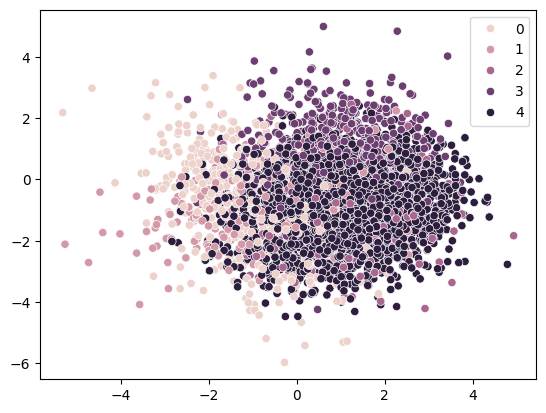

In [12]:
sns.scatterplot(
    x =X.T[2],
    y = X.T[3],
    hue = Y
)

### Random Over sampling 

In [13]:
from imblearn.over_sampling import RandomOverSampler

Random Over-Sampling Counts: dict_items([(np.int64(4), 3467), (np.int64(3), 3467), (np.int64(0), 3467), (np.int64(2), 3467), (np.int64(1), 3467)])


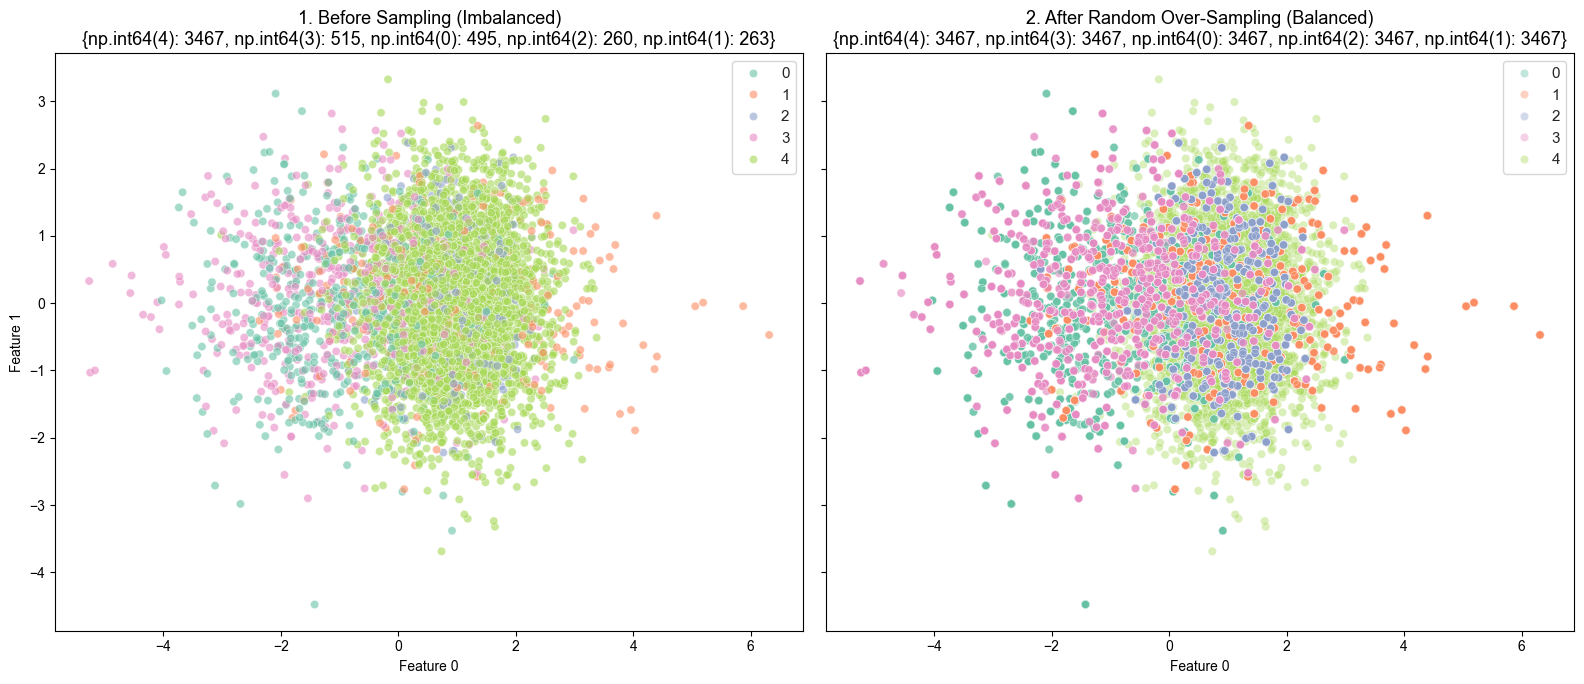

In [14]:
ros = RandomOverSampler(random_state=42)
X_ros, Y_ros = ros.fit_resample(X, Y)
print("Random Over-Sampling Counts:", Counter(Y_ros).items())
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
sns.set_theme(style="whitegrid")
# --- LEFT PLOT: RANDOM OVER-SAMPLED DATA --
sns.scatterplot(
    x=X.T[0], 
    y=X.T[1], 
    hue=Y, 
    palette="Set2", 
    ax=axes[0], 
    alpha=0.6
)
axes[0].set_title(f"1. Before Sampling (Imbalanced)\n{dict(Counter(Y))}", fontsize=13)
axes[0].set_xlabel("Feature 0")
axes[0].set_ylabel("Feature 1")

# --- RIGHT PLOT: RANDOM OVER-SAMPLED DATA ---
sns.scatterplot(
    x=X_ros.T[0], 
    y=X_ros.T[1], 
    hue=Y_ros, 
    palette="Set2", 
    ax=axes[1], 
    alpha=0.4  # Slightly transparent to show density of overlapping clones
)
axes[1].set_title(f"2. After Random Over-Sampling (Balanced)\n{dict(Counter(Y_ros))}", fontsize=13)
axes[1].set_xlabel("Feature 0")

plt.tight_layout()
plt.show()

### SMOTE

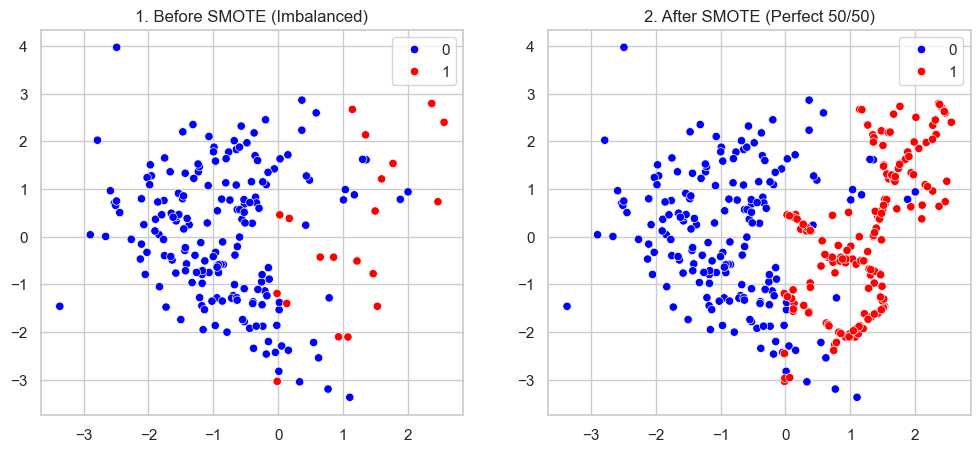

In [15]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

X, y = make_classification(
    n_samples=200, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    weights=[0.9, 0.1], 
    random_state=42
    )

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=X.T[0], y=X.T[1], hue=y, palette={0: "blue", 1: "red"}, ax=axes[0])
axes[0].set_title("1. Before SMOTE (Imbalanced)")

sns.scatterplot(x=X_balanced.T[0], y=X_balanced.T[1], hue=y_balanced, palette={0: "blue", 1: "red"}, ax=axes[1])
axes[1].set_title("2. After SMOTE (Perfect 50/50)")

plt.show()
